In [2]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt

### Using the ISFDB list of eligible SFF books

In [3]:
isfdb_books = pd.read_csv('data/isfdb_novels_06-06.csv', delimiter=',')

In [4]:
isfdb_books.head(5)

,title_id,title,type,author,first_publication_year,synopsis,tags,first_isbn,first_publisher,openlibrary_id
0,1,The Warrior Who Carried Life,NOVEL,Geoff Ryman,1985,<b>From the back cover of the Bantam paperback...,"bsfa award for best novel finalist, fantasy, f...",0044407777,Unwin Paperbacks,NaN
1,4,The Winds of Altair,NOVEL,Ben Bova,1973,NaN,"science fiction, young-adult sf",0727817760,Severn House,NaN
2,6,Empire Builders,NOVEL,Ben Bova,1993,NaN,science fiction,0812511654,Tor,NaN
3,7,Privateers,NOVEL,Ben Bova,1985,NaN,science fiction,0812534891,Tor,NaN
4,8,Star Brothers,NOVEL,Ben Bova,1990,NaN,"nanotechnology, science fiction",0312932154,Tor,NaN


<Axes: >

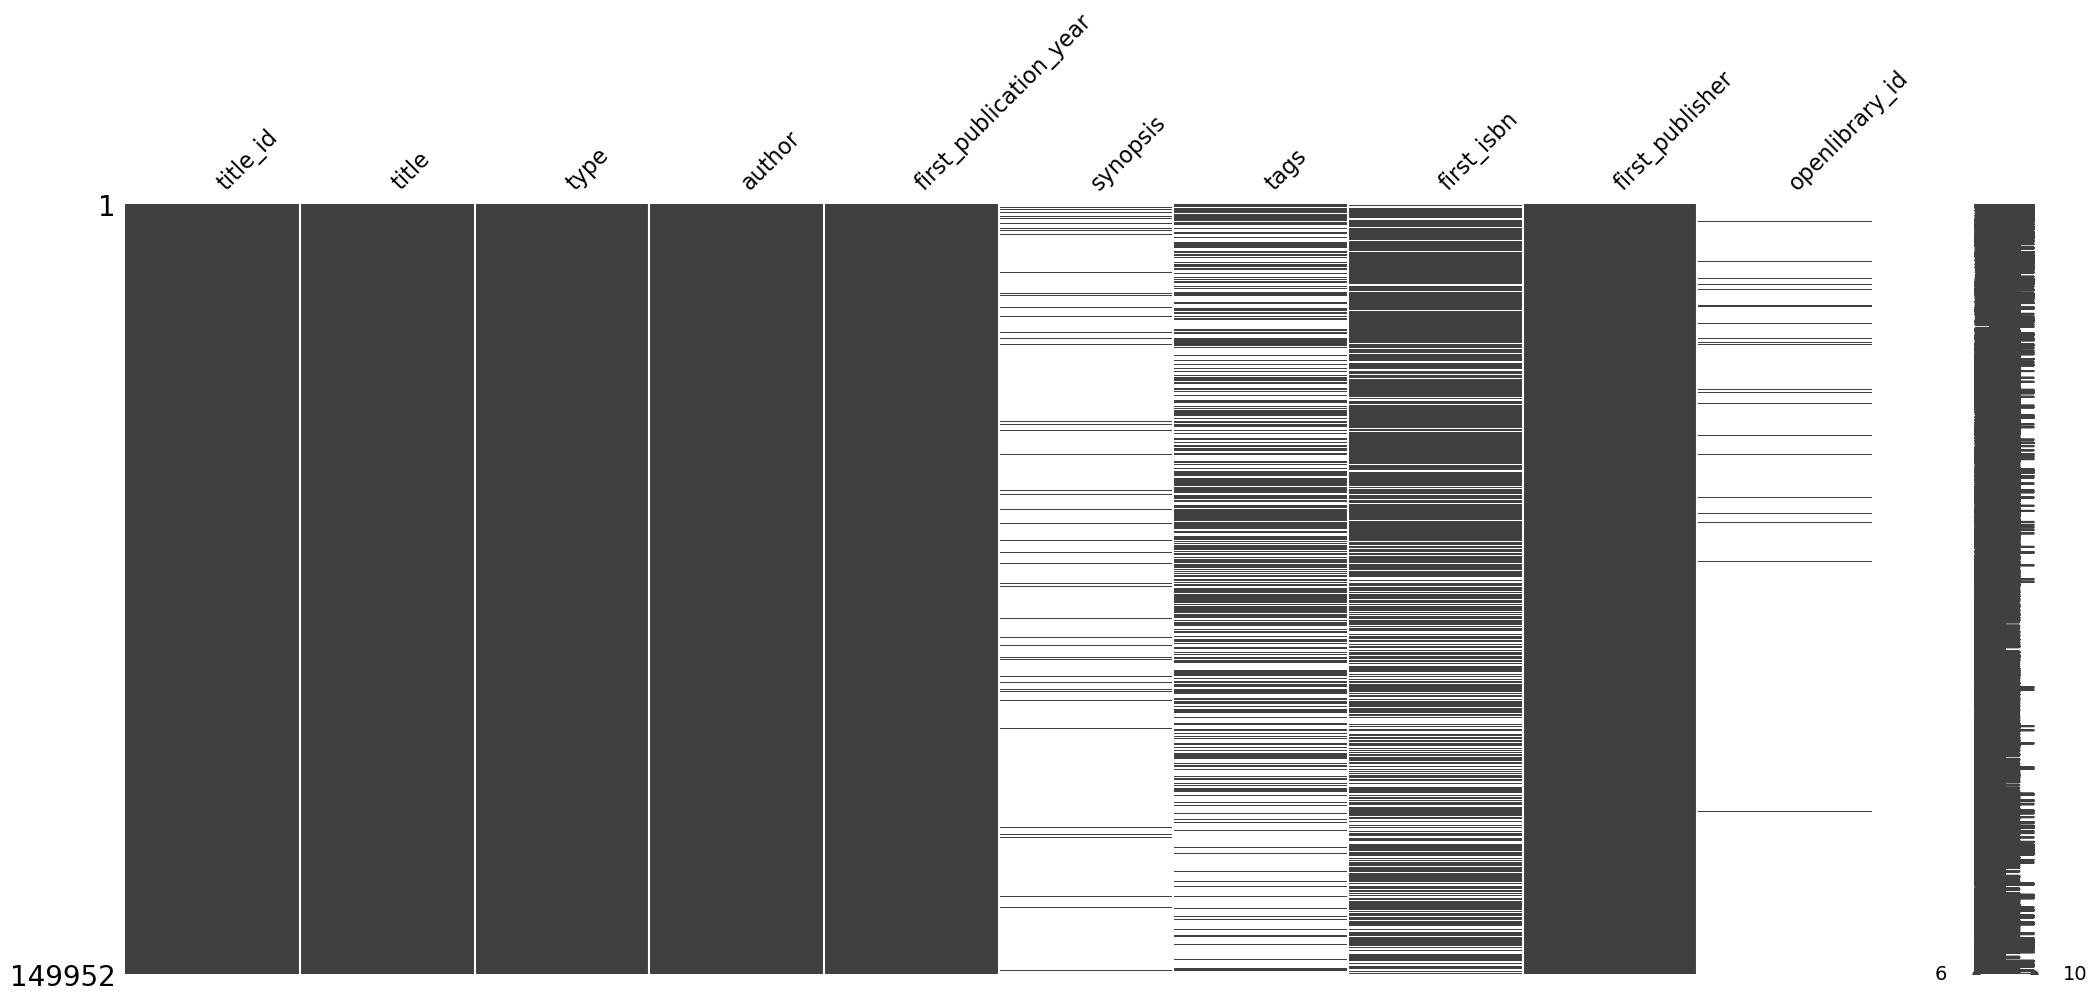

In [5]:
msno.matrix(isfdb_books)

<Axes: >

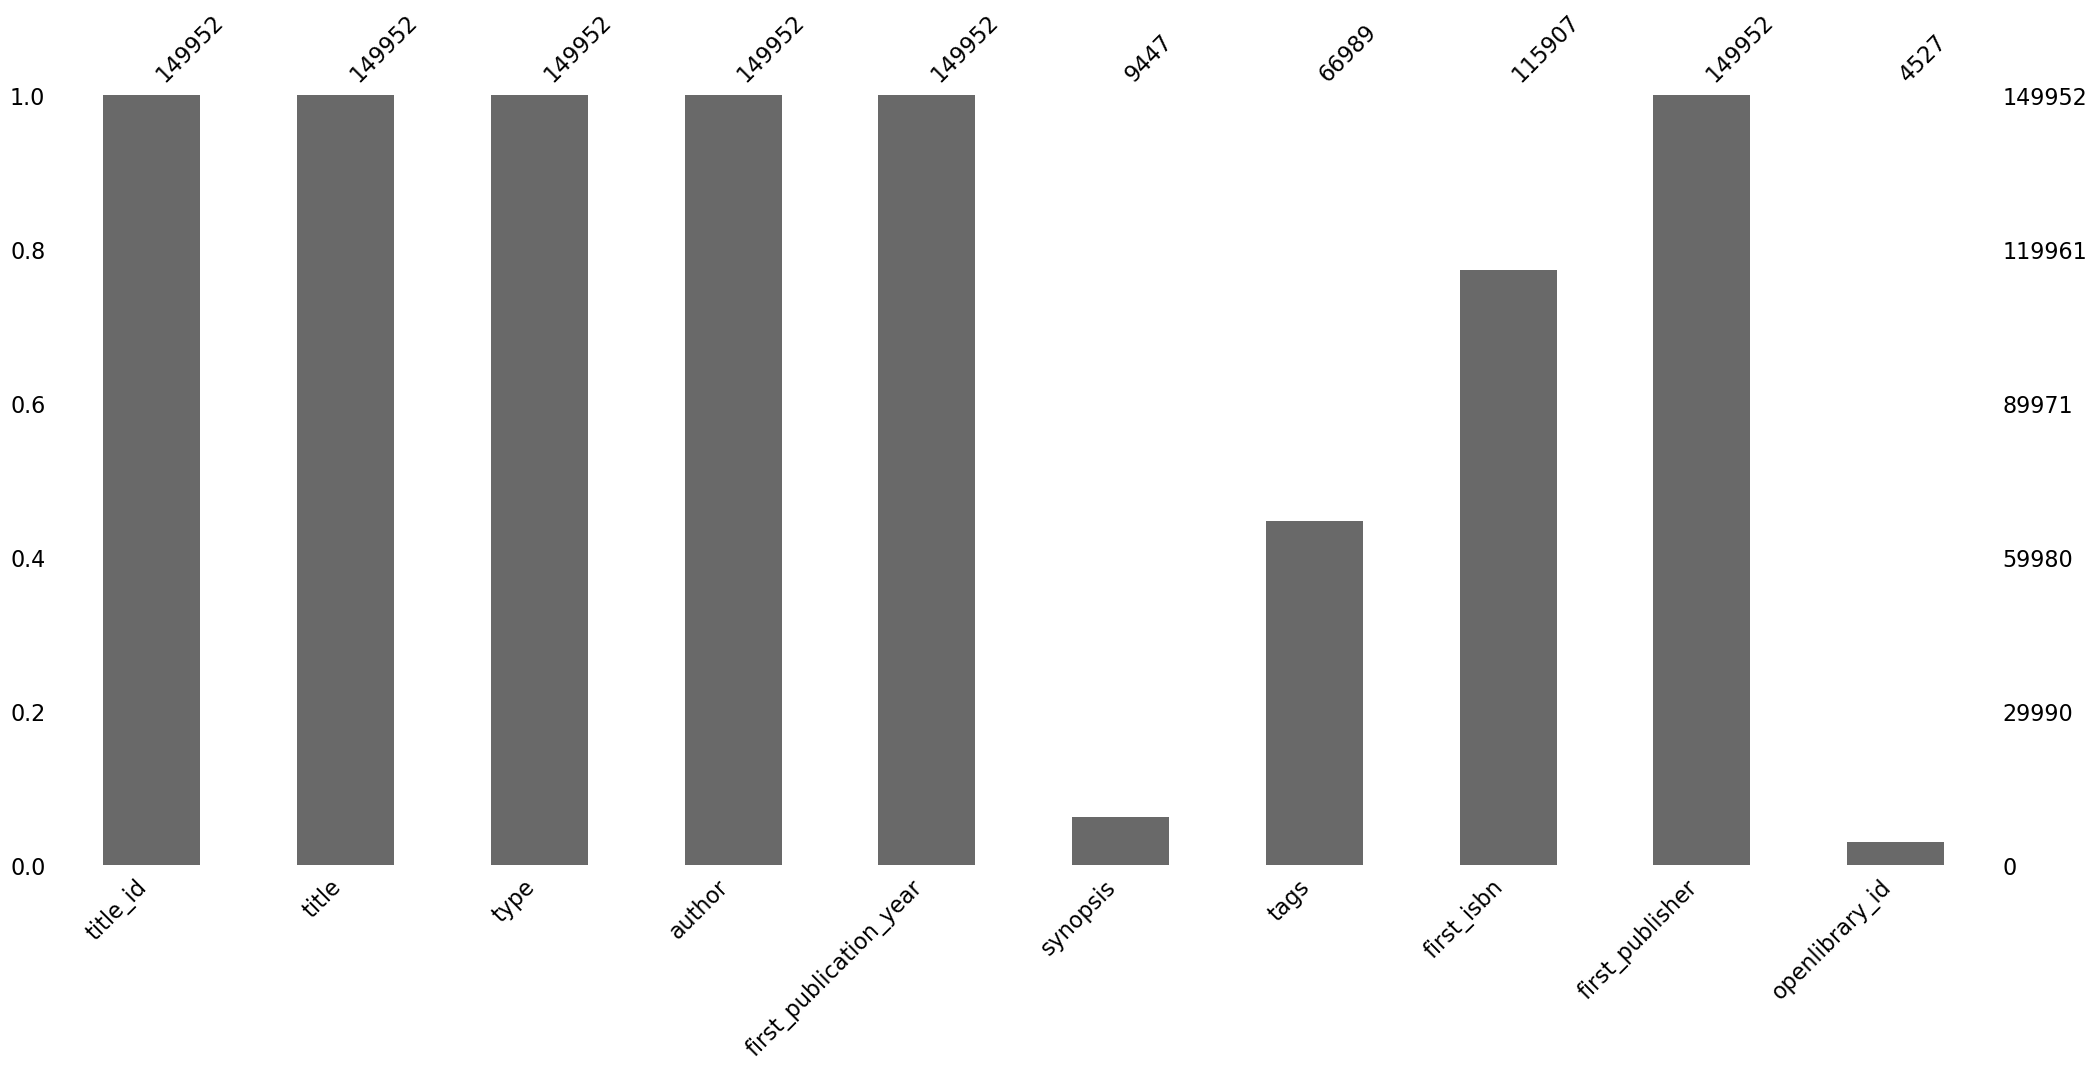

In [6]:
msno.bar(isfdb_books)

A bit less than 50% of these books have associated tags, and only a small fraction have a synopsis :(

### Open Library Works

Contains title of works + their description, for all works which contain a description.

In [7]:
ol_works = pd.read_csv("data/openlibrary_works-descriptions.csv")

In [8]:
ol_works.head(5)

,work_id,title,description
0,/works/OL1000384W,Salem on Trial (Sabrina the Teenage Witch #8),The eighth in a series of novelizations accomp...
1,/works/OL1000828W,Falling,"In Falling, Christopher Pike explores the dept..."
2,/works/OL10008448W,The cosmic microwave background,The cosmic microwave background (CMB) is the r...
3,/works/OL10080210W,The Sepulchrum Domini Through the Ages,"Throughout the centuries, commemoration of the..."
4,/works/OL1008041W,Keith Jarrett no blue note,"""Impressive Jazz Improvisations are accomplish..."


In [9]:
# tried to merge the two datasets together, with matching titles, to increase the number of entries with either
# synopsis or description

merged_works = pd.merge(isfdb_books, ol_works, on='title', how='left')

merged_works = merged_works.sort_values('description', key=lambda x: x.str.len(), na_position='last') \
                            .drop_duplicates(subset='title_id', keep='first')
merged_works = merged_works.sort_values('title_id').reset_index(drop=True)


<Axes: >

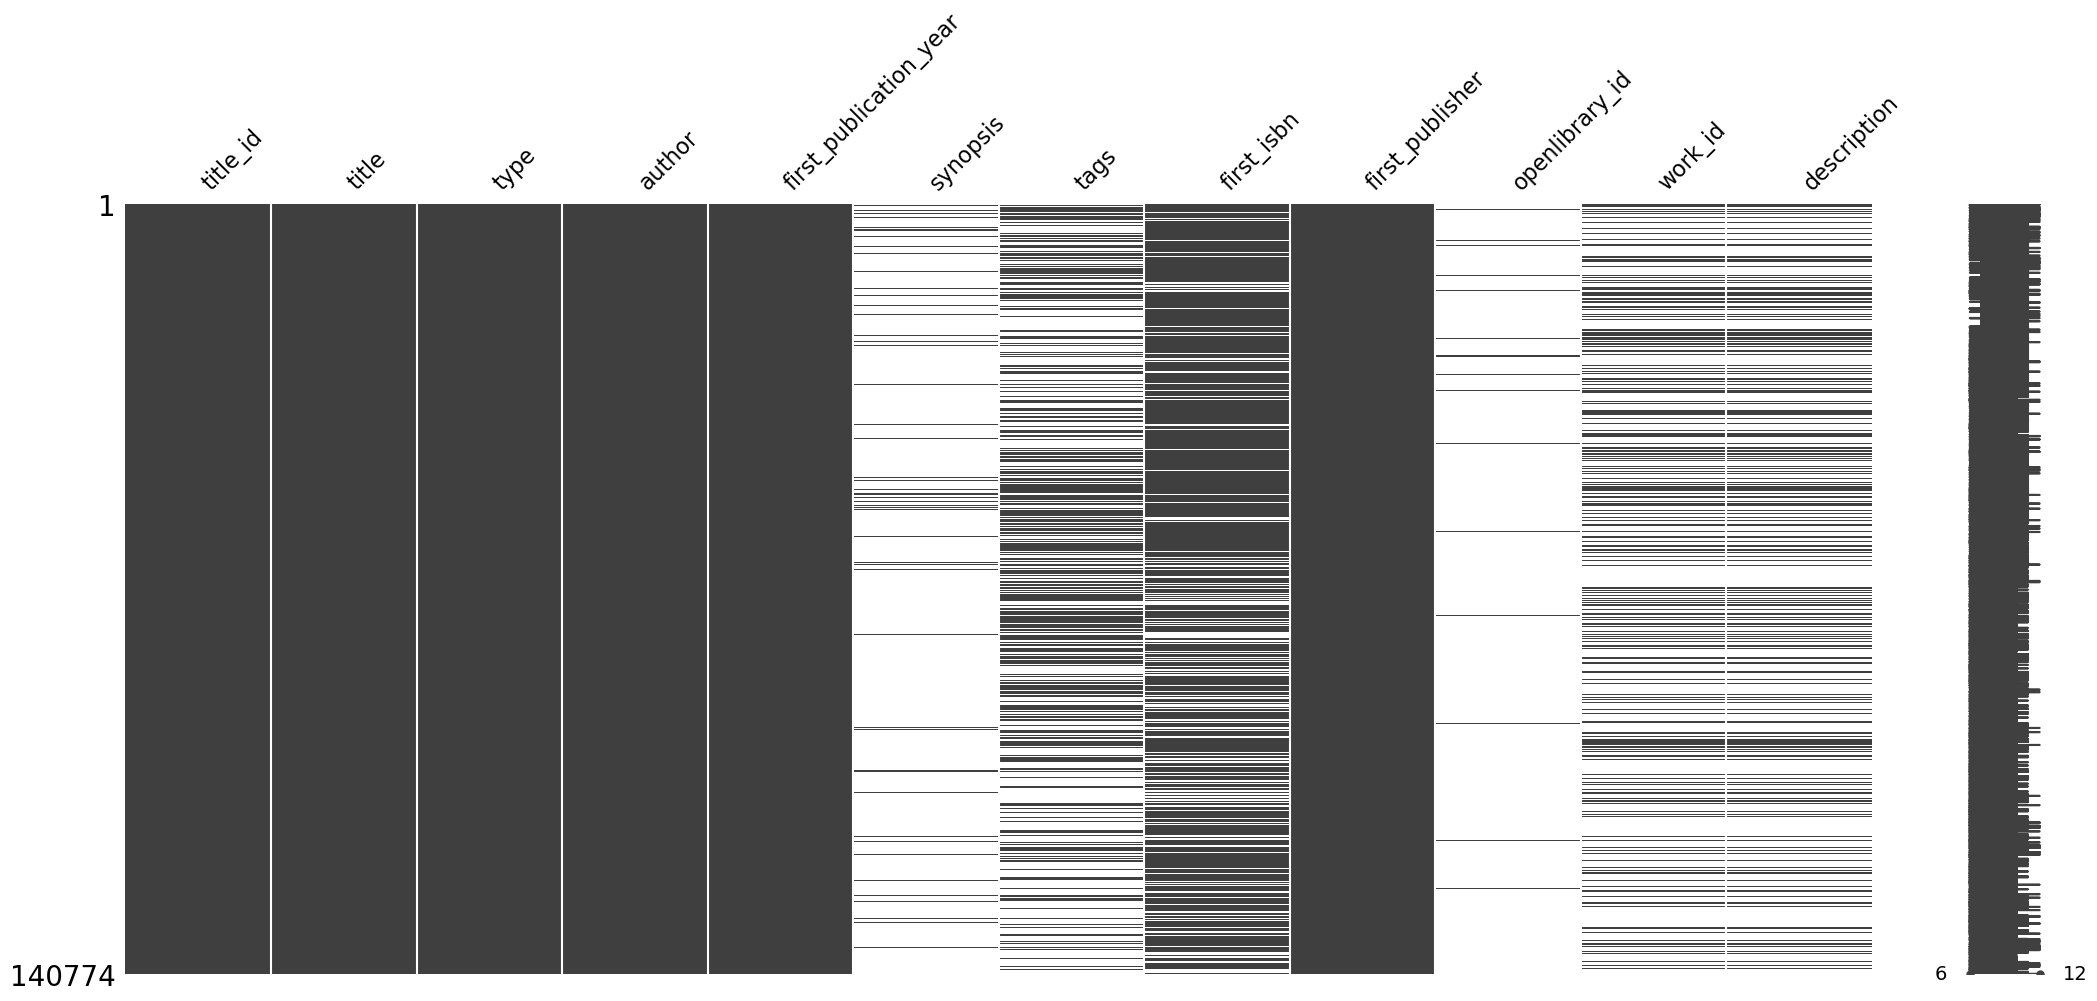

In [33]:
msno.matrix(merged_works)

### Open Library Book Reviews

In [34]:
ol_reviews = pd.read_csv("data/openlibrary_reviews.csv")

In [35]:
ol_reviews

,work_id,star_rating,date
0,/works/OL17882343W,3,2018-06-20
1,/works/OL1629179W,5,2018-06-20
2,/works/OL4226036W,5,2018-06-20
3,/works/OL5264255W,5,2018-06-20
4,/works/OL1681415W,5,2018-06-20
...,...,...,...
621719,/works/OL461939W,3,2022-07-30
621720,/works/OL1708091W,3,2022-07-30
621721,/works/OL8299102W,4,2022-07-30
621722,/works/OL15191772W,4,2022-07-30


In [36]:
works_cumulative_reviews = ol_reviews.groupby('work_id', as_index=False).agg(
    num_reviews=('star_rating', 'count'),
    avg_rating=('star_rating', 'mean')
)

In [37]:
works_cumulative_reviews

,work_id,num_reviews,avg_rating
0,/works/OL10000000W,1,3.0
1,/works/OL100001W,1,1.0
2,/works/OL1000035W,1,4.0
3,/works/OL1000043W,1,3.0
4,/works/OL100004W,1,3.0
...,...,...,...
287708,/works/OL99997W,1,4.0
287709,/works/OL999981W,5,3.4
287710,/works/OL999982W,2,5.0
287711,/works/OL999983W,1,5.0


In [38]:
ol_reviews_titles = pd.merge(ol_works, works_cumulative_reviews, on = 'work_id', how = 'left')
ol_reviews_titles = ol_reviews_titles.drop_duplicates(subset='work_id', keep='first')
ol_reviews_titles = ol_reviews_titles.sort_values('work_id').reset_index(drop=True)


In [39]:
ol_reviews_titles.head(5)

,work_id,title,description,num_reviews,avg_rating
0,/works/OL10000083W,Sahara,One of the greatest artistic photography colle...,NaN,NaN
1,/works/OL10000123W,"Rimun Iddah, jumhuriyat al-damir","On Rīmūn Iddah, 1913-; politicians; Lebanon; p...",NaN,NaN
2,/works/OL10000127W,Masarat al-salam wa-diblumasiyat al-425,Israeli-Arab conflect; peace process; diplomacy.,NaN,NaN
3,/works/OL10000132W,al-Nass wa-al-rasas,Islamic fundamentalism; Egypt.,NaN,NaN
4,/works/OL10000134W,Azmat al-maliyah al-ammah fi Lubnan,Finance; Economic policy; Lebanon.,NaN,NaN


<Axes: >

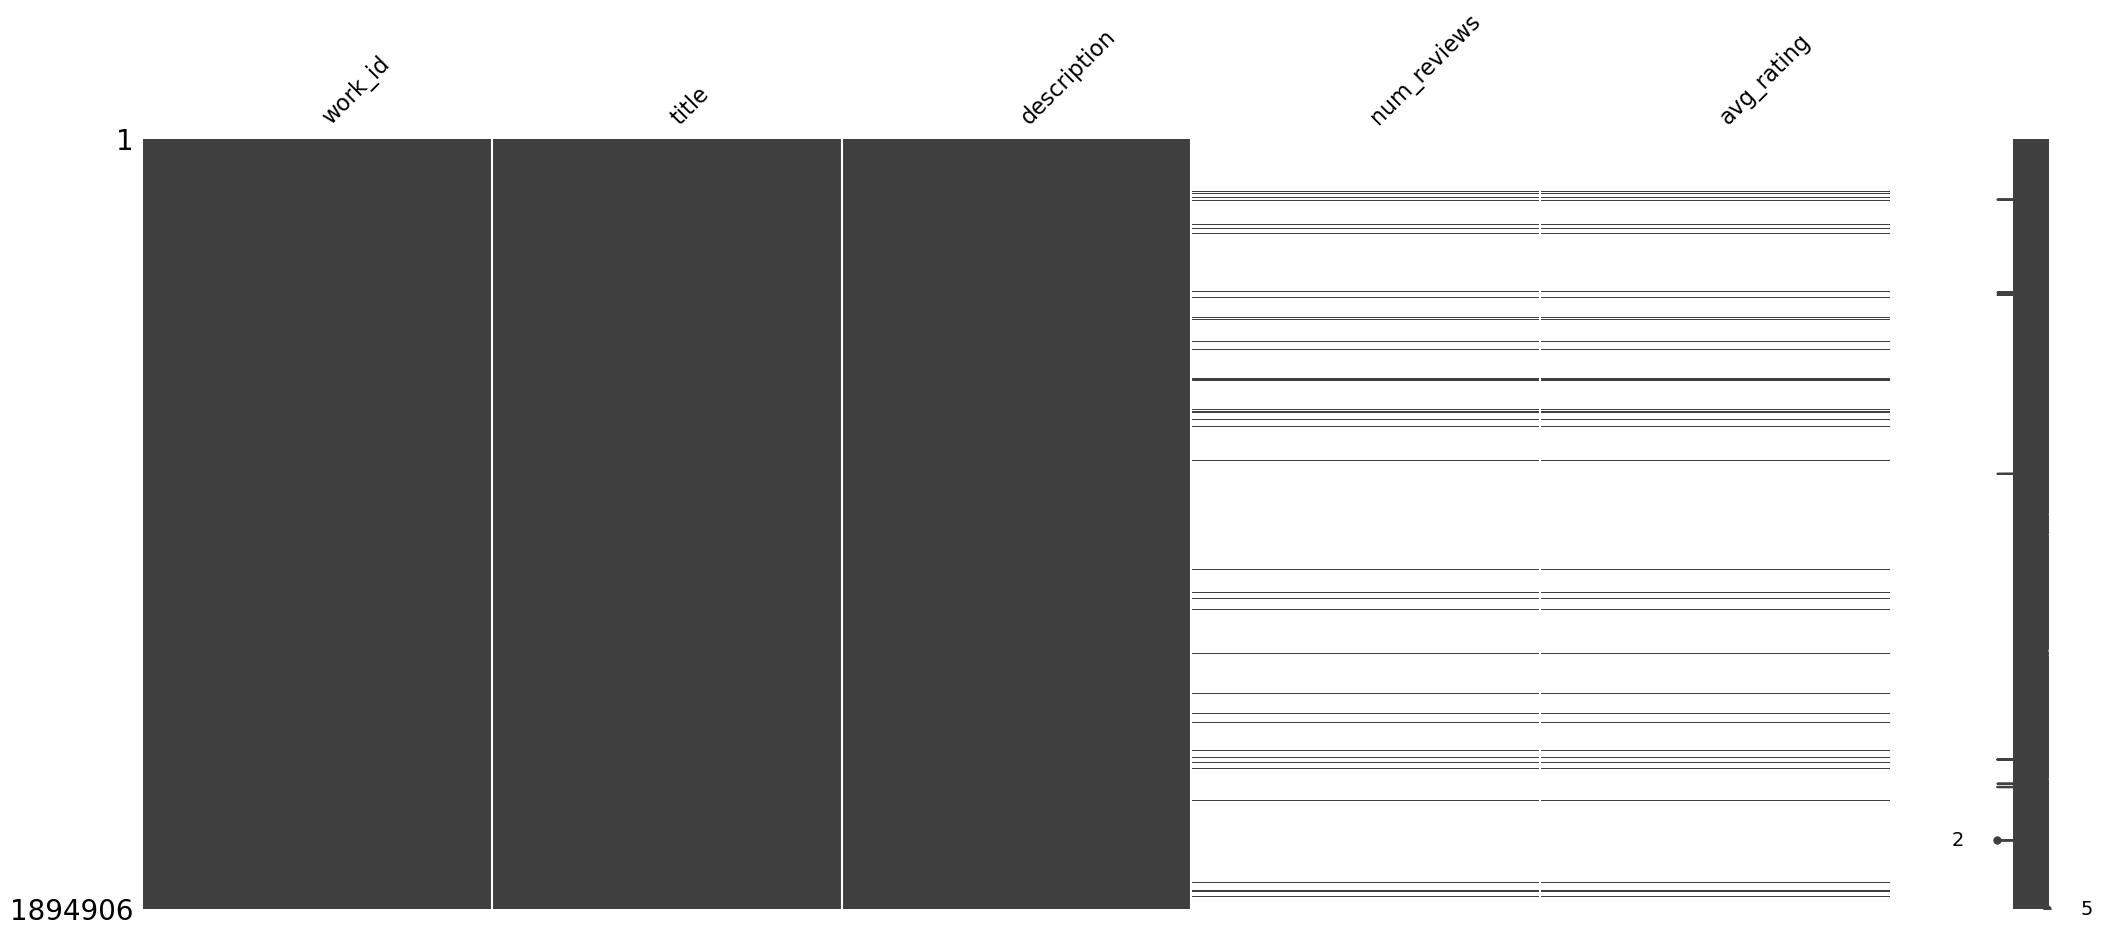

In [40]:
msno.matrix(ol_reviews_titles)


Not many of the Open Library books have associated user ratings

In [ ]:
merged_works_reviews = pd.merge(merged_works, ol_reviews_titles, on='title', how='left')
merged_works_reviews = merged_works_reviews.drop_duplicates(subset='title_id', keep='first')

<Axes: >

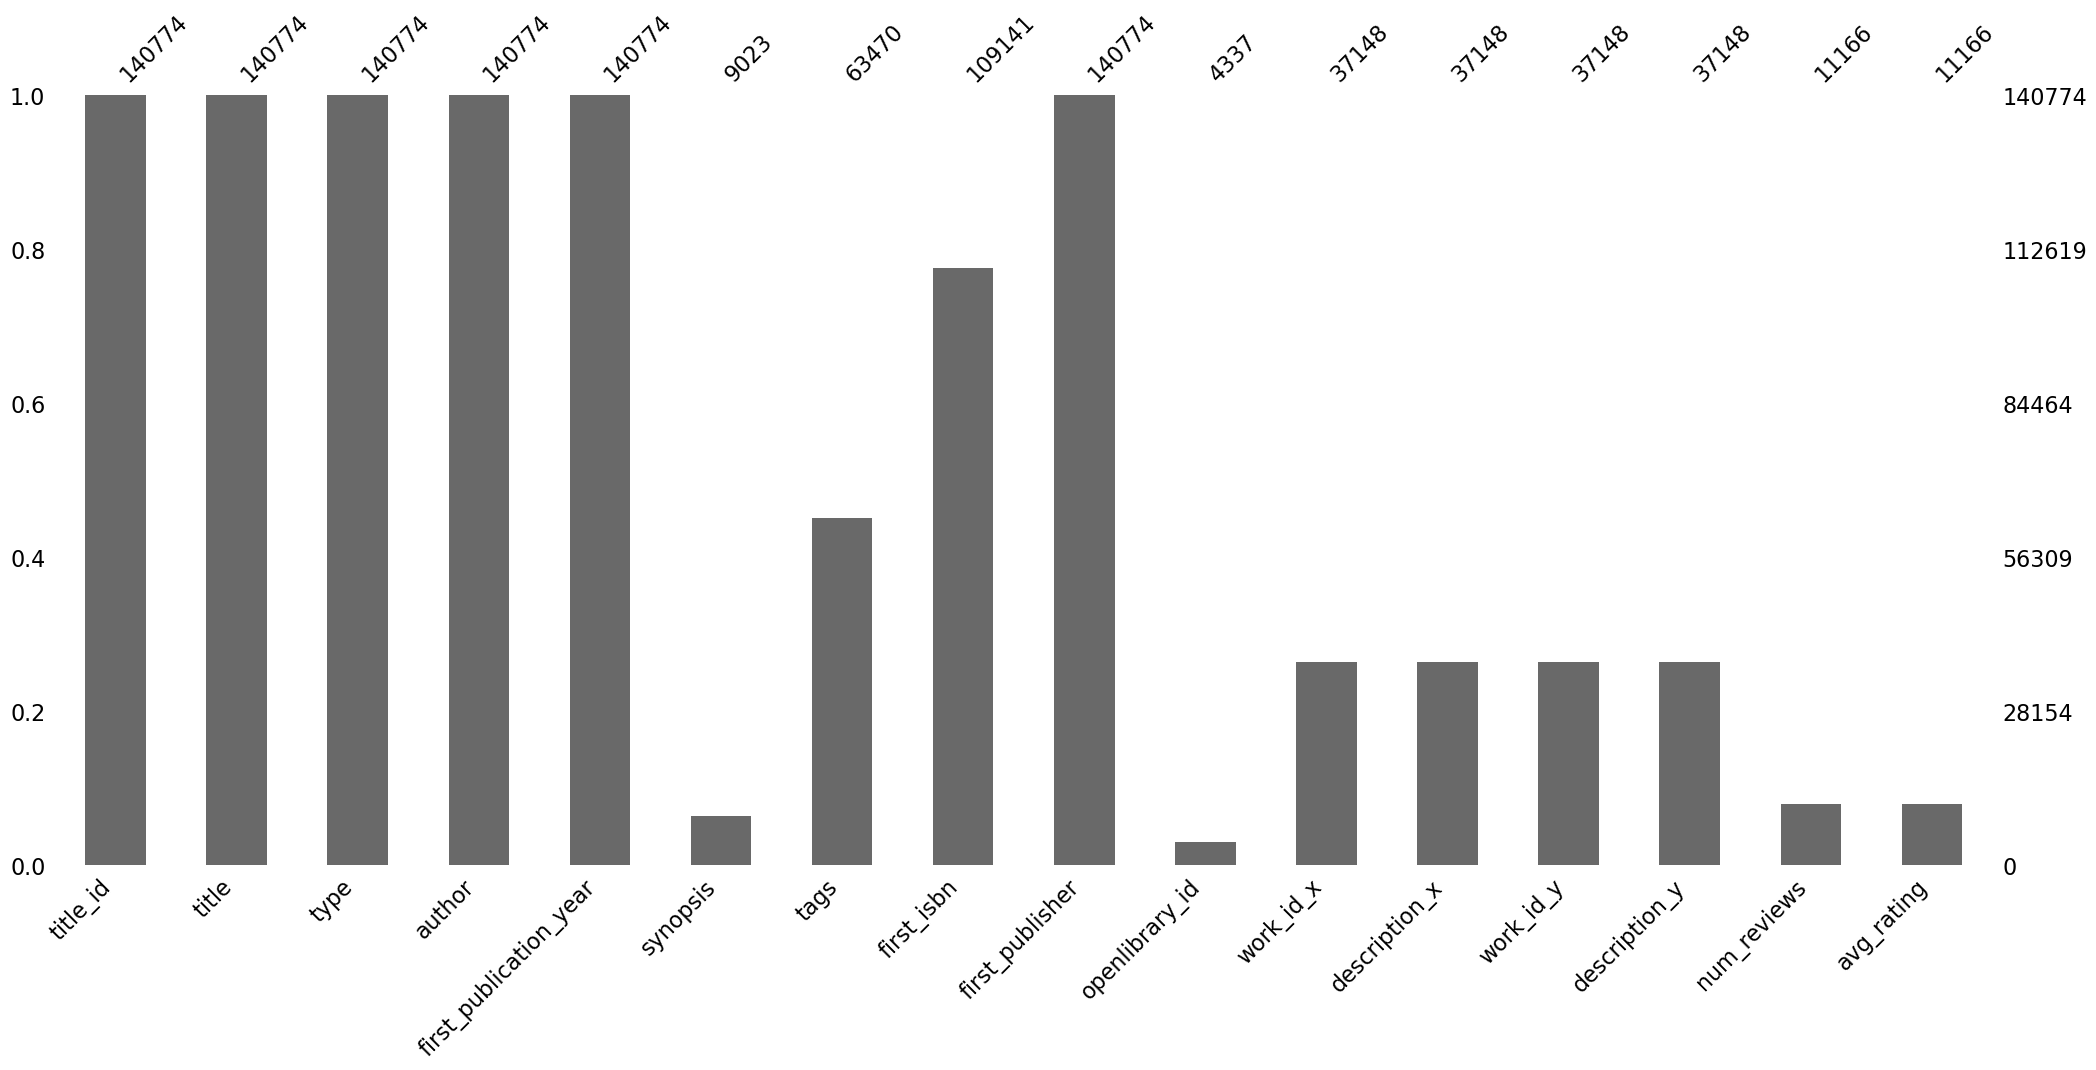

In [47]:
msno.bar(merged_works_reviews)


when merging with the ISFDB dataset, less than 1/10 of the books have an associated rating. Not great :(

Ultimately, ISFDB is good for getting initial dataset of books and their metadata, but even with ISFDB + OpenLibrary, we don't have sufficient ratings and book tags...